In [1]:
!pip install -q ultralytics roboflow seaborn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 20.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.9/207.9 kB 14.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.8/66.8 kB 4.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 49.9/49.9 MB 40.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 65.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.5/5.5 MB 113.7 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
google-adk 1.25.1 requires google-cloud-bigquery-storage>=2.0.0, which is not installed.
gcsfs 2025.3.0 requires fsspec==2025.3.0, but you have fsspec 2026.2.0 which is incompatible.


In [2]:
import os
import shutil
import zipfile
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from roboflow import Roboflow
from ultralytics import YOLO
from ultralytics import RTDETR
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from IPython.display import display

Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.


In [3]:
rf = Roboflow(api_key="MwMGKFDELBAjDBLkMA86")
project = rf.workspace("test-1cbw8").project("traffic-wy5ag-3drvy")
version = project.version(1)
dataset = version.download("yolov8")

DATA_YAML = dataset.location + "/data.yaml"

print("Dataset path:", dataset.location)
print("YAML:", DATA_YAML)

loading Roboflow workspace...
loading Roboflow project...



Extracting Dataset Version Zip to traffic-1 in yolov8:: 100%|██████████| 569/569 [00:00<00:00, 9858.55it/s]

Dataset path: /kaggle/working/traffic-1
YAML: /kaggle/working/traffic-1/data.yaml


In [4]:
model_list = [
    {"name": "1_YOLOv8n_Baseline", "weights": "yolov8n.pt"},
    {"name": "2_YOLOv10n_Efficiency", "weights": "yolov10n.pt"},
    {"name": "3_YOLOv11n_Latest", "weights": "yolo11n.pt"},
    {"name": "4_YOLOv9c_Complex", "weights": "yolov9c.pt"},
    {"name": "5_RTDETR_Hybrid", "weights": "rtdetr-l.pt"}
]

In [5]:
OUTPUT_DIR = "/kaggle/working/final_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

In [6]:
results_summary = []

for item in model_list:
    model_name = item["name"]
    weights = item["weights"]

    print("\n" + "="*70)
    print(f"TRAINING: {model_name}")
    print("="*70)

    try:
        if "rtdetr" in weights.lower():
            model = RTDETR(weights)
        else:
            model = YOLO(weights)

        train_results = model.train(
            data=DATA_YAML,
            epochs=50,
            imgsz=640,
            batch=16,
            device=[0,1],
            workers=8,
            cache=True,
            amp=True,
            optimizer="auto",
            project="traffic_benchmark",
            name=model_name,
            pretrained=True,
            patience=15,
            save=True,
            verbose=True
        )

        metrics = model.val()

        map50 = float(metrics.box.map50)
        map5095 = float(metrics.box.map)
        precision = float(metrics.box.mp)
        recall = float(metrics.box.mr)

        results_summary.append({
            "Model": model_name,
            "Weights": weights,
            "mAP50": map50,
            "mAP50-95": map5095,
            "Precision": precision,
            "Recall": recall
        })

        print(f"\nCompleted: {model_name}")

    except Exception as e:
        print(f"Error with {model_name}: {e}")


TRAINING: 1_YOLOv8n_Baseline
Ultralytics 8.4.53 🚀 Python-3.12.12 torch-2.10.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
                                                       CUDA:1 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=True, cfg=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/kaggle/working/traffic-1/data.yaml, degrees=0.0, deterministic=True, device=0,1, dfl=1.5, dnn=False, dropout=0.0, dynamic=False, embed=None, end2end=None, epochs=50, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, half=False, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, int8=False, iou=0.7, keras=False, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_s

/usr/local/lib/python3.12/dist-packages/ultralytics/utils/metrics.py:99: UserWarning: Specified kernel cache directory could not be created! This disables kernel caching. Specified directory is /root/.cache/torch/kernels. This warning will appear only once per process. (Triggered internally at /pytorch/aten/src/ATen/native/cuda/jit_utils.cpp:1487.)
  inter = (torch.min(a2, b2) - torch.max(a1, b1)).clamp_(0).prod(2)


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 1.6it/s 1.2s
                   all         56       1321     0.0382      0.321      0.103     0.0627

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       2/50      1.36G      1.191       1.92       1.12          3        640: 100% ━━━━━━━━━━━━ 13/13 6.4it/s 2.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 6.9it/s 0.3s
                   all         56       1321      0.904     0.0783      0.135     0.0935

      Epoch    GPU_mem   box_loss   cls_loss   dfl_loss  Instances       Size
       3/50      1.49G      1.171      1.666       1.11          3        640: 100% ━━━━━━━━━━━━ 13/13 6.0it/s 2.2s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 2/2 7.8it/s 0.3s
                   all         56       1321      0.688  

[rank0]: Traceback (most recent call last):
[rank0]:   File "/root/.config/Ultralytics/DDP/_temp_bfv5tyvy136130137149648.py", line 19, in <module>
[rank0]:     results = trainer.train()
[rank0]:               ^^^^^^^^^^^^^^^
[rank0]:   File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/trainer.py", line 246, in train
[rank0]:     self._do_train()
[rank0]:   File "/usr/local/lib/python3.12/dist-packages/ultralytics/engine/trainer.py", line 450, in _do_train
[rank0]:     loss, self.loss_items = self.model(batch)
[rank0]:                             ^^^^^^^^^^^^^^^^^
[rank0]:   File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1776, in _wrapped_call_impl
[rank0]:     return self._call_impl(*args, **kwargs)
[rank0]:            ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
[rank0]:   File "/usr/local/lib/python3.12/dist-packages/torch/nn/modules/module.py", line 1787, in _call_impl
[rank0]:     return forward_call(*args, **kwargs)
[rank0]:            ^^^^^^^^^

Error with 5_RTDETR_Hybrid: Command '['/usr/bin/python3', '-m', 'torch.distributed.run', '--nproc_per_node', '2', '--master_port', '49503', '/root/.config/Ultralytics/DDP/_temp_bfv5tyvy136130137149648.py']' returned non-zero exit status 1.


In [7]:
results_df = pd.DataFrame(results_summary)
results_df = results_df.sort_values(by="mAP50-95", ascending=False)

csv_path = os.path.join(OUTPUT_DIR, "benchmark_results.csv")
results_df.to_csv(csv_path, index=False)

print(results_df)

                   Model      Weights     mAP50  mAP50-95  Precision    Recall
3      4_YOLOv9c_Complex   yolov9c.pt  0.807267  0.560829   0.725588  0.815189
0     1_YOLOv8n_Baseline   yolov8n.pt  0.797276  0.547066   0.696121  0.829753
2      3_YOLOv11n_Latest   yolo11n.pt  0.782751  0.541304   0.681266  0.820680
1  2_YOLOv10n_Efficiency  yolov10n.pt  0.733161  0.497672   0.689715  0.719108


In [8]:
display(results_df)

,Model,Weights,mAP50,mAP50-95,Precision,Recall
3,4_YOLOv9c_Complex,yolov9c.pt,0.807267,0.560829,0.725588,0.815189
0,1_YOLOv8n_Baseline,yolov8n.pt,0.797276,0.547066,0.696121,0.829753
2,3_YOLOv11n_Latest,yolo11n.pt,0.782751,0.541304,0.681266,0.820680
1,2_YOLOv10n_Efficiency,yolov10n.pt,0.733161,0.497672,0.689715,0.719108


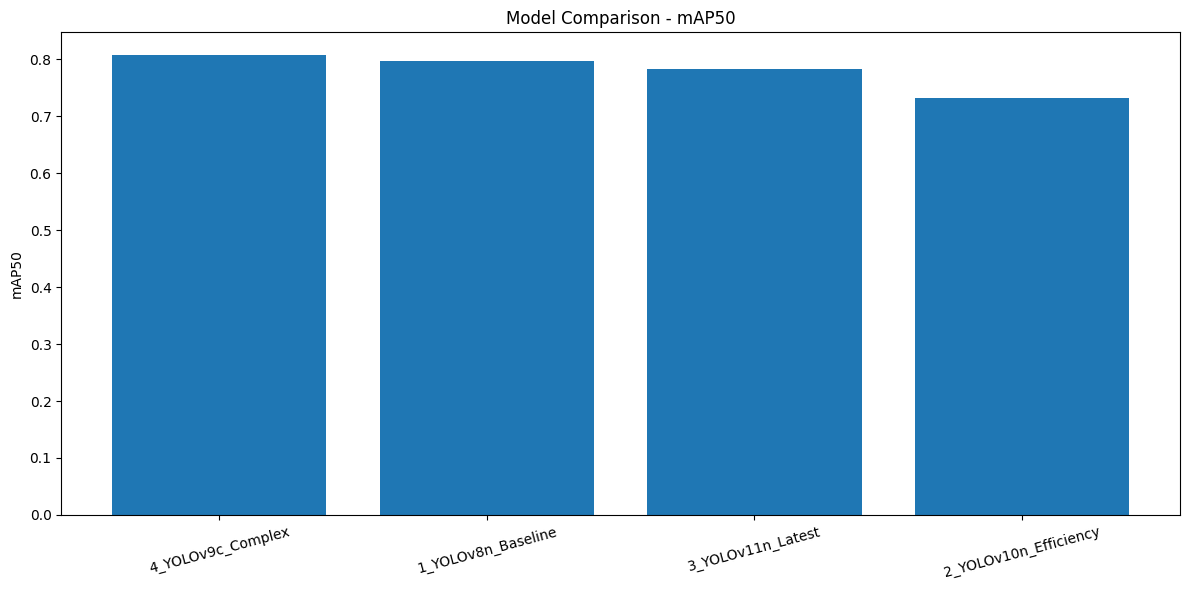

In [9]:
plt.figure(figsize=(12,6))
plt.bar(results_df["Model"], results_df["mAP50"])
plt.xticks(rotation=15)
plt.ylabel("mAP50")
plt.title("Model Comparison - mAP50")
plt.tight_layout()

map50_chart = os.path.join(OUTPUT_DIR, "map50_comparison.png")
plt.savefig(map50_chart)
plt.show()

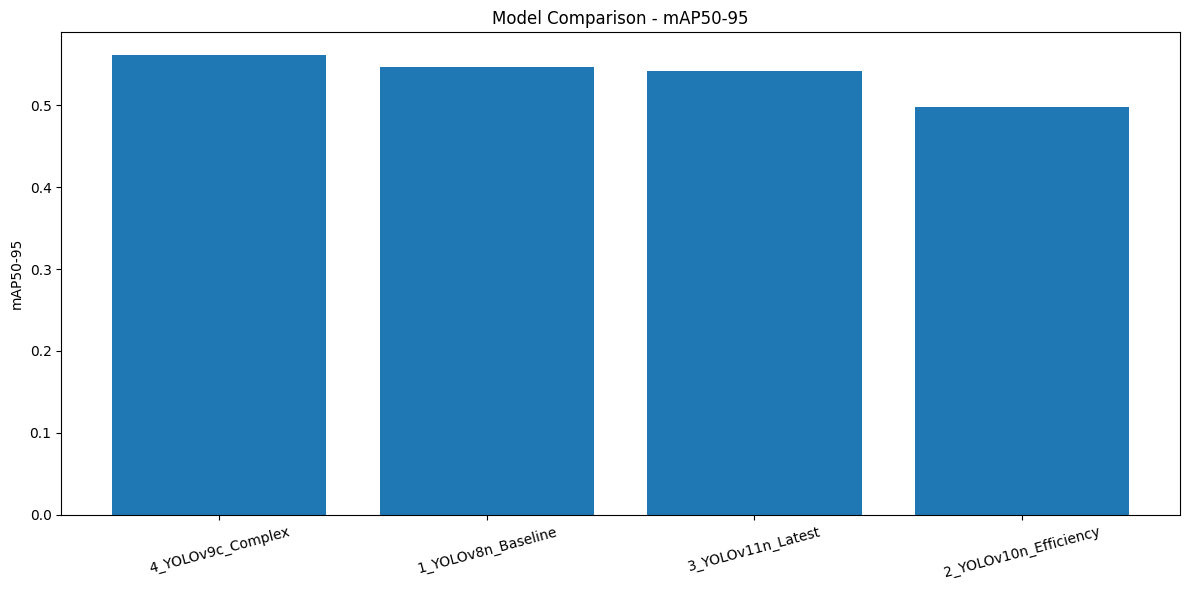

In [10]:
plt.figure(figsize=(12,6))
plt.bar(results_df["Model"], results_df["mAP50-95"])
plt.xticks(rotation=15)
plt.ylabel("mAP50-95")
plt.title("Model Comparison - mAP50-95")
plt.tight_layout()

map5095_chart = os.path.join(OUTPUT_DIR, "map5095_comparison.png")
plt.savefig(map5095_chart)
plt.show()

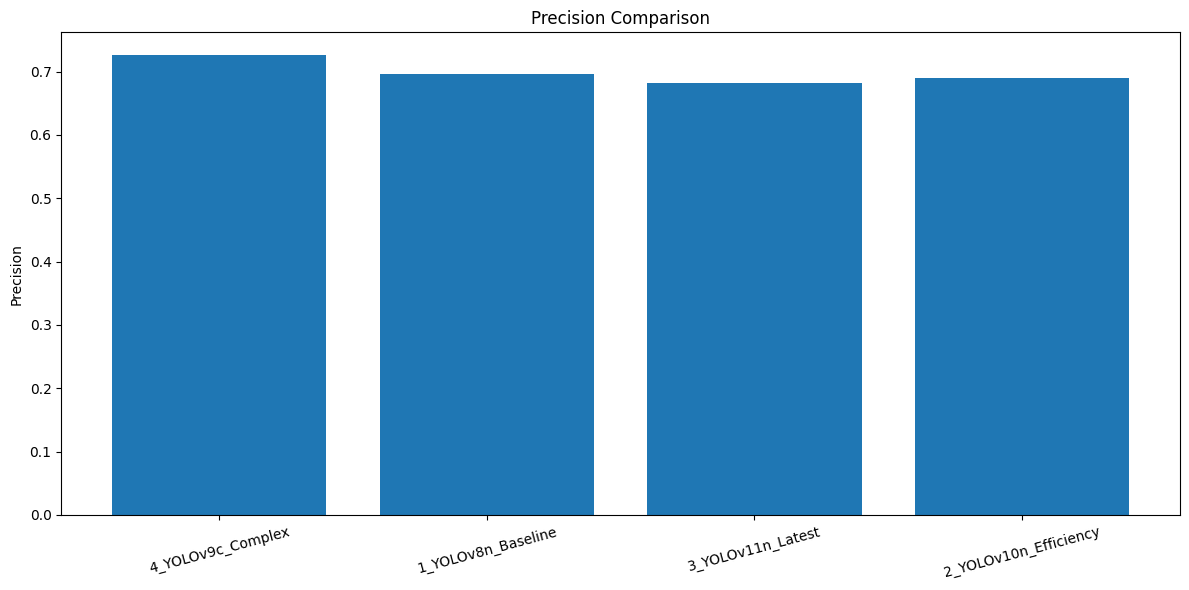

In [11]:
plt.figure(figsize=(12,6))
plt.bar(results_df["Model"], results_df["Precision"])
plt.xticks(rotation=15)
plt.ylabel("Precision")
plt.title("Precision Comparison")
plt.tight_layout()

precision_chart = os.path.join(OUTPUT_DIR, "precision_comparison.png")
plt.savefig(precision_chart)
plt.show()

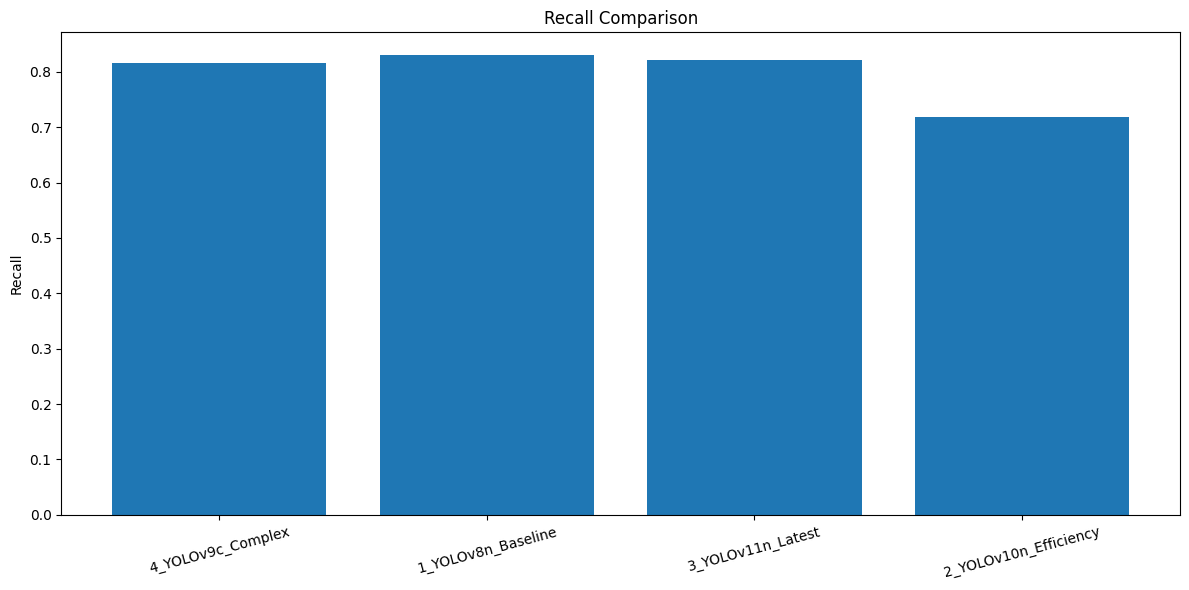

In [12]:
plt.figure(figsize=(12,6))
plt.bar(results_df["Model"], results_df["Recall"])
plt.xticks(rotation=15)
plt.ylabel("Recall")
plt.title("Recall Comparison")
plt.tight_layout()

recall_chart = os.path.join(OUTPUT_DIR, "recall_comparison.png")
plt.savefig(recall_chart)
plt.show()

In [13]:
TRAIN_DIR = "/kaggle/working/traffic_benchmark"
FINAL_TRAIN_COPY = os.path.join(OUTPUT_DIR, "all_training_results")

if os.path.exists(FINAL_TRAIN_COPY):
    shutil.rmtree(FINAL_TRAIN_COPY)

shutil.copytree(TRAIN_DIR, FINAL_TRAIN_COPY)

print("Copied training folders")

FileNotFoundError: [Errno 2] No such file or directory: '/kaggle/working/traffic_benchmark'

In [ ]:
best_model_name = results_df.iloc[0]["Model"]
print("Best model:", best_model_name)

In [ ]:
best_weights = os.path.join(
    TRAIN_DIR,
    best_model_name,
    "weights",
    "best.pt"
)

print(best_weights)

In [ ]:
best_model = YOLO(best_weights)
val_metrics = best_model.val(save_json=True)

In [ ]:
BEST_MODEL_OUTPUT = os.path.join(OUTPUT_DIR, "best_model.pt")
shutil.copy(best_weights, BEST_MODEL_OUTPUT)

print("Saved best model")

In [ ]:
readme_text = f'''
Traffic Detection Benchmark Results

Best Model:
{best_model_name}

Summary:
{results_df.to_string(index=False)}
'''

with open(os.path.join(OUTPUT_DIR, "README.txt"), "w") as f:
    f.write(readme_text)

In [ ]:
import os
import shutil

OUTPUT_DIR = "/kaggle/working/final_outputs"
os.makedirs(OUTPUT_DIR, exist_ok=True)

FINAL_TRAIN_COPY = os.path.join(OUTPUT_DIR, "all_training_results")

possible_dirs = [
    "/kaggle/working/traffic_benchmark",
    "/kaggle/working/runs",
    "/kaggle/working/runs/detect"
]

found_dir = None

for d in possible_dirs:
    if os.path.exists(d):
        found_dir = d
        break

if found_dir is not None:

    print(f"Found training directory: {found_dir}")

    if os.path.exists(FINAL_TRAIN_COPY):
        shutil.rmtree(FINAL_TRAIN_COPY)

    shutil.copytree(found_dir, FINAL_TRAIN_COPY)

    print("Training results copied successfully.")

else:
    print("No training directory found.")
    print("Listing Kaggle working directory:")

    for item in os.listdir("/kaggle/working"):
        print(item)